In [43]:
import requests

currencies = {
    'USD' : 1,
    'GBP' : 2,
    'EUR' : 3,
    'CHF' : 4,
    'RUB' : 5,
    'KRW' : 16,
    'CAD' : 20,
}

appid = '730'
country = 'SE'
currency = 3
steamLoginSecure = ''

url = 'http://steamcommunity.com/market/pricehistory'


In [44]:

"""

Navaja, Talon, Ursus, Stiletto

"""

assets = [
    'Antwerp 2022 Legends Sticker Capsule',
    'Antwerp 2022 Challengers Sticker Capsule',
    'Antwerp 2022 Contenders Sticker Capsule',
    'Stockholm 2021 Contenders Sticker Capsule',
    'Stockholm 2021 Challengers Sticker Capsule',
    'Stockholm 2021 Legends Sticker Capsule',
]


In [45]:
data = {}

for asset in assets:
    url = 'http://steamcommunity.com/market/pricehistory'
    history = requests.get(
        url, 
        params={
        'appid': appid,
        'market_hash_name': asset,
        'country': country,
        'currency': currency,
      },
        cookies={
            'steamLoginSecure': steamLoginSecure,
        }
    )
    data[asset] = history.json()['prices']
    

In [49]:
import numpy as np
dataset = {}
for asset in assets:
    dataset[asset] = {}
    dataset[asset]['price'] = np.array([p[1] for p in data[asset]])
    dataset[asset]['time'] = np.array([p[0].split(':')[0] for p in data[asset]])
    dates = []
    for t in dataset[asset]['time']:
        month, day, year, time = t.split(' ')
        dtime = datetime(int(year), m2n[month], int(day), int(time))
        dates.append(dtime)
    dataset[asset]['ntime'] = matplotlib.dates.date2num(dates)
    print(f'asset\t`{asset}`\thas {len(dataset[asset]["price"])} samples')
    

asset	`Antwerp 2022 Legends Sticker Capsule`	has 1046 samples
asset	`Antwerp 2022 Challengers Sticker Capsule`	has 1046 samples
asset	`Antwerp 2022 Contenders Sticker Capsule`	has 1046 samples
asset	`Stockholm 2021 Contenders Sticker Capsule`	has 1238 samples
asset	`Stockholm 2021 Challengers Sticker Capsule`	has 1234 samples
asset	`Stockholm 2021 Legends Sticker Capsule`	has 1239 samples


In [68]:
print(dataset['Antwerp 2022 Legends Sticker Capsule']['time'])

['May 11 2022 01' 'May 12 2022 01' 'May 13 2022 01' ... 'May 02 2023 16'
 'May 02 2023 17' 'May 02 2023 18']


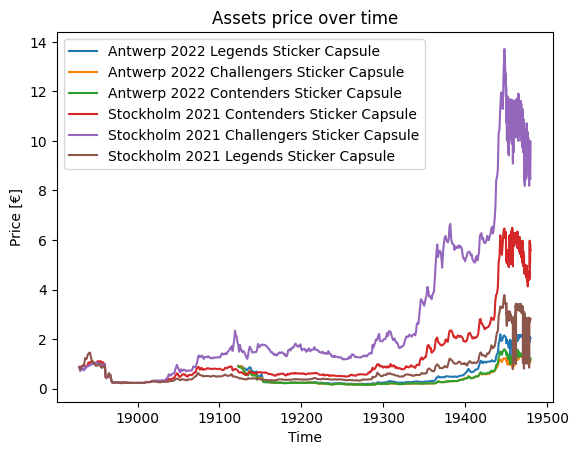

In [15]:
from datetime import datetime
import matplotlib.dates
import calendar
import matplotlib.pyplot as plt

m2n = {m: i for i, m in enumerate(calendar.month_abbr)}
del[m2n['']]

for asset in assets:
    plt.plot(dataset[asset]['ntime'], dataset[asset]['price'], label=asset)

plt.title('Assets price over time')
plt.ylabel('Price [€]')
plt.xlabel('Time')
plt.legend(loc='best')
plt.show()


In [17]:
latest_date = -10000

for asset in assets:
    if dataset[asset]['ntime'][0] > latest_date:
        latest_date = dataset[asset]['ntime'][0]

print(latest_date)

19123.041666666668


In [50]:
mod_dataset = {}
for a in assets:
    mod_dataset[a] = {}
    # idx = list(dataset[a]['ntime']).index(latest_date)
    lenn = len(dataset[a]['price'])
    numm = lenn - 1046
    mod_dataset[a]['price'] = dataset[a]['price'][numm:]
    mod_dataset[a]['time'] = dataset[a]['time'][numm:]
    mod_dataset[a]['ntime'] = dataset[a]['ntime'][numm:]
    
    print(mod_dataset[a]['ntime'].shape)


(1046,)
(1046,)
(1046,)
(1046,)
(1046,)
(1046,)


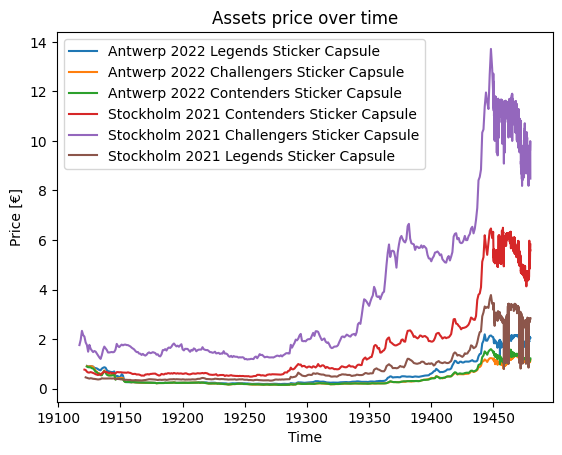

In [51]:
for asset in assets:
    plt.plot(mod_dataset[asset]['ntime'], mod_dataset[asset]['price'], label=asset)

plt.title('Assets price over time')
plt.ylabel('Price [€]')
plt.xlabel('Time')
plt.legend(loc='best')
plt.show()


In [79]:
averages = []

def divv(a, b):
    return a / b

for s in assets:
    xd = mod_dataset[s]['price'][1:]
    xdd = mod_dataset[s]['price'][:-1]
    _div = np.vectorize(divv)
    period_returns = _div(xd, xdd) - 1
    averages.append(period_returns.mean())

averages = np.array(averages)
covariance = np.cov([mod_dataset[s]['price'] for s in assets])

print(averages)
print(covariance)


[0.00170418 0.00071785 0.00092238 0.00278388 0.00272399 0.0133731 ]
[[ 0.53436603  0.29571398  0.34133678  1.48753632  2.70626901  0.80827372]
 [ 0.29571398  0.16738521  0.19024869  0.8040105   1.46916868  0.44381048]
 [ 0.34133678  0.19024869  0.22282229  0.95600792  1.74635713  0.52047533]
 [ 1.48753632  0.8040105   0.95600792  4.51922019  8.12608802  2.34353522]
 [ 2.70626901  1.46916868  1.74635713  8.12608802 15.16788359  4.27154166]
 [ 0.80827372  0.44381048  0.52047533  2.34353522  4.27154166  1.29817931]]


In [148]:
from itertools import product
import random

s2i = {s: i for i, s in enumerate(assets)}

portfolio_ratios = []
portfolio_returns = []
portfolio_volatility = []

bounds = [range(0, 10) for _ in range(len(assets))]
n_samples = 5000

portfolios = random.sample(list(product(*bounds)), n_samples)

for perm in product(portfolios):
    x = np.array(perm)[0]
    if (x == 0).all():
        continue
    
    portfolio_returns.append(x.T.dot(averages))
    portfolio_volatility.append(np.sqrt(x.T.dot(covariance).dot(x)))
    portfolio_ratios.append(portfolio_returns[-1]/portfolio_volatility[-1])
    if portfolio_ratios[-1] > 0.01:
        print(perm)

pr = np.array(portfolio_ratios)
pr = (pr - pr.mean()) / pr.std()

In [151]:
anton = np.array([10, 10, 10, 0, 0, 0])

antonmu = anton.T.dot(averages)
antonvol = np.sqrt(anton.T.dot(covariance).dot(x))

opt = np.array([0, 0, 2, 0, 0, 4])
optmu = opt.T.dot(averages)
optvol = np.sqrt(opt.T.dot(covariance).dot(opt))

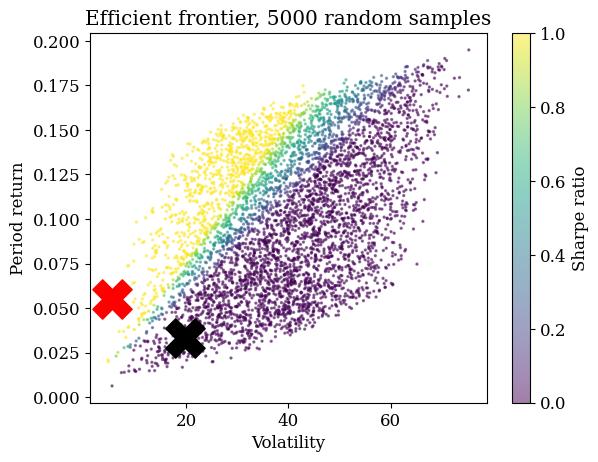

In [152]:
import matplotlib
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 12
cmap = matplotlib.colormaps.get_cmap('viridis')
colors = [cmap(s) for s in pr]
scatter = plt.scatter(portfolio_volatility, portfolio_returns, s=2.0, alpha=0.5, c=colors)
plt.scatter(antonvol, antonmu, marker='X', s=800.0, c='black', alpha=1.0)
plt.scatter(optvol, optmu, marker='X', s=800.0, c='red', alpha=1.0)
plt.colorbar(scatter, label='Sharpe ratio')
plt.xlabel('Volatility')
plt.ylabel('Period return')
plt.title(f'Efficient frontier, {n_samples} random samples')
plt.show()


In [6]:
quantity = {}
quantity['Clutch Case'] = 119437
quantity['Danger Zone Case'] = 183661
quantity['Prisma 2 Case'] = 108733
quantity['Prisma Case'] = 101701
quantity['Horizon Case'] = 58031


Prisma Case: 6.784594055122368e-06
Prisma 2 Case: 6.667708975196123e-06
Horizon Case: 1.333769881614999e-05
Clutch Case: 8.464713614709009e-06
Danger Zone Case: 3.7678113480815195e-06


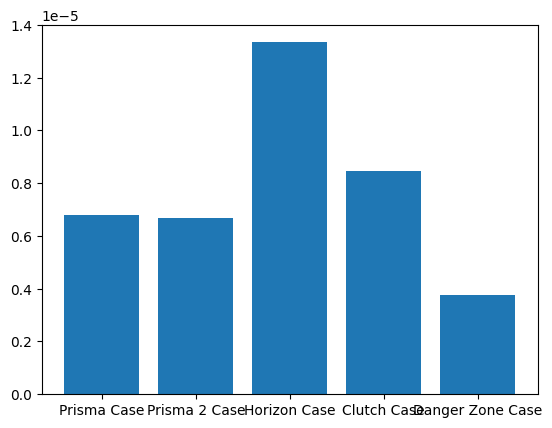

In [7]:
qp = []
for asset in assets:
    q = quantity[asset]
    p = dataset[asset]['price'][-1]
    print(f'{asset}: {p/q}')
    qp.append(p/q)
    
plt.bar(assets, qp)
plt.show()
    

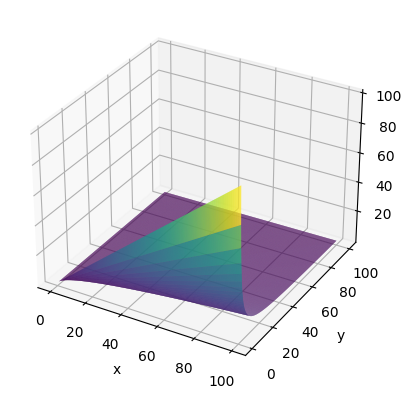

In [8]:
p = np.linspace(0.03, 100, num=300)
q = np.linspace(1, 100, num=300)
x, y = np.meshgrid(p, q)

z = x / y

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', rstride=1, cstride=1)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()


In [9]:
opened = {}
opened['Clutch Case'] = 4263675
opened['Horizon Case'] = 752136
opened['Danger Zone Case'] = 1610281
opened['Prisma Case'] = 1076868
opened['Prisma 2 Case'] = 2180436


In [10]:
"""

Opened, o
Quantity, q
Price, p

många öppnar lådan -> metric bli stor

o / q

"""

'\n\nOpened, o\nQuantity, q\nPrice, p\n\nmånga öppnar lådan -> metric bli stor\n\no / q\n\n'

Prisma Case: 10.58856845065437
Prisma 2 Case: 20.05312094764239
Horizon Case: 12.960934672847271
Clutch Case: 35.69810862630508
Danger Zone Case: 8.767680672543436


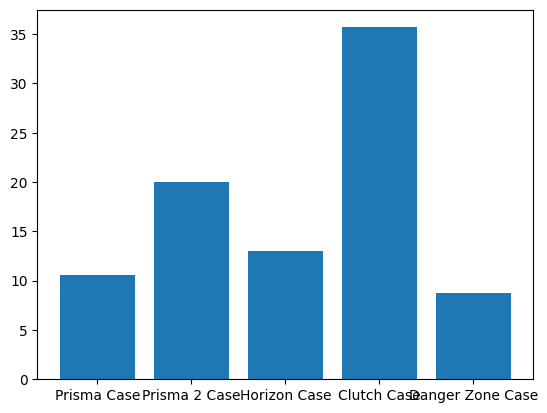

In [11]:
oq = []
for asset in assets:
    q = quantity[asset]
    o = opened[asset]
    print(f'{asset}: {o/q}')
    oq.append(o/q)
    
plt.bar(assets, oq)
plt.show()


Prisma Case: 15.345751377759958
Prisma 2 Case: 27.659477169161917
Horizon Case: 16.745393634169602
Clutch Case: 35.30970190534627
Danger Zone Case: 12.670058775351787


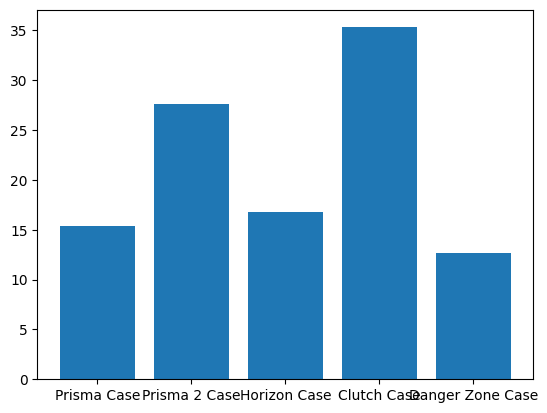

In [12]:
opq = []
for asset in assets:
    q = quantity[asset]
    o = opened[asset]
    p = dataset[asset]['price'][-1]
    print(f'{asset}: {o/(p*q)}')
    opq.append(o/(p*q))
    
plt.bar(assets, opq)
plt.show()
